# 03 (macro). Ключевая ставка ЦБ РФ и инфляция

Небольшой анализ макро-фона рынка за период данных (ноя.2020 – апр.2026): динамика
ключевой ставки и инфляции (г/г) относительно цели ЦБ (4%) и реальная ставка.
Контекст: ставка → стоимость ипотеки → спрос на первичку (важно для эластичности).


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd().resolve()
REPO_ROOT = _cwd if (_cwd / "data").is_dir() else _cwd.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.config import MACRO_XLSX

C1, C2, C3 = "#2C7BB6", "#D7542B", "#2D9E5F"
plt.rcParams.update({"figure.dpi": 150, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.right": False, "axes.spines.top": False})

FIG_DIR = REPO_ROOT / "reports" / "figures" / "03_eda_macro"
FIG_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
raw = pd.read_excel(MACRO_XLSX)
raw.columns = [str(c).strip() for c in raw.columns]

# 'Дата' хранится как float (M.YYYY); у 2020 теряется хвостовой ноль (12.2020 -> 12.202).
# Парсим: месяц = floor(v), год = round((v - месяц) * 10000).
v = raw["Дата"].astype(float)
month = np.floor(v).astype(int)
year  = ((v - month) * 10000).round().astype(int)

macro = pd.DataFrame({
    "date":      pd.to_datetime(dict(year=year, month=month, day=1)),
    "key_rate":  raw["Ключевая ставка, % годовых"].astype(float),
    "inflation": raw["Инфляция, % г/г"].astype(float),
    "target":    raw["Цель по инфляции"].astype(float),
}).sort_values("date").reset_index(drop=True)

macro["real_rate"] = macro["key_rate"] - macro["inflation"]   # реальная ставка, п.п.

print(f"Период: {macro['date'].min():%Y-%m} … {macro['date'].max():%Y-%m}  ({len(macro)} мес.)")
display(macro.head(3))
display(macro.tail(3))


Период: 2020-11 … 2026-04  (66 мес.)


,date,key_rate,inflation,target,real_rate
0,2020-11-01,4.25,4.4,4.0,-0.15
1,2020-12-01,4.25,4.9,4.0,-0.65
2,2021-01-01,4.25,5.2,4.0,-0.95


,date,key_rate,inflation,target,real_rate
63,2026-02-01,15.5,5.91,4.0,9.59
64,2026-03-01,15.0,5.86,4.0,9.14
65,2026-04-01,14.5,5.58,4.0,8.92


In [3]:
last = macro.iloc[-1]
kr_max = macro.loc[macro["key_rate"].idxmax()]
inf_max = macro.loc[macro["inflation"].idxmax()]
above = (macro["inflation"] > macro["target"]).mean()

print(f"Текущие ({last['date']:%Y-%m}):  ставка {last['key_rate']:.2f}%   инфляция {last['inflation']:.2f}%   реальная {last['real_rate']:.2f} п.п.")
print(f"Пик ставки:     {kr_max['key_rate']:.2f}%  ({kr_max['date']:%Y-%m})")
print(f"Пик инфляции:   {inf_max['inflation']:.2f}%  ({inf_max['date']:%Y-%m})")
print(f"Инфляция выше цели (4%): {above:.0%} месяцев")
print(f"Корреляция ставка↔инфляция: {macro['key_rate'].corr(macro['inflation']):.2f}")


Текущие (2026-04):  ставка 14.50%   инфляция 5.58%   реальная 8.92 п.п.
Пик ставки:     21.00%  (2024-10)
Пик инфляции:   17.83%  (2022-04)
Инфляция выше цели (4%): 94% месяцев
Корреляция ставка↔инфляция: 0.22


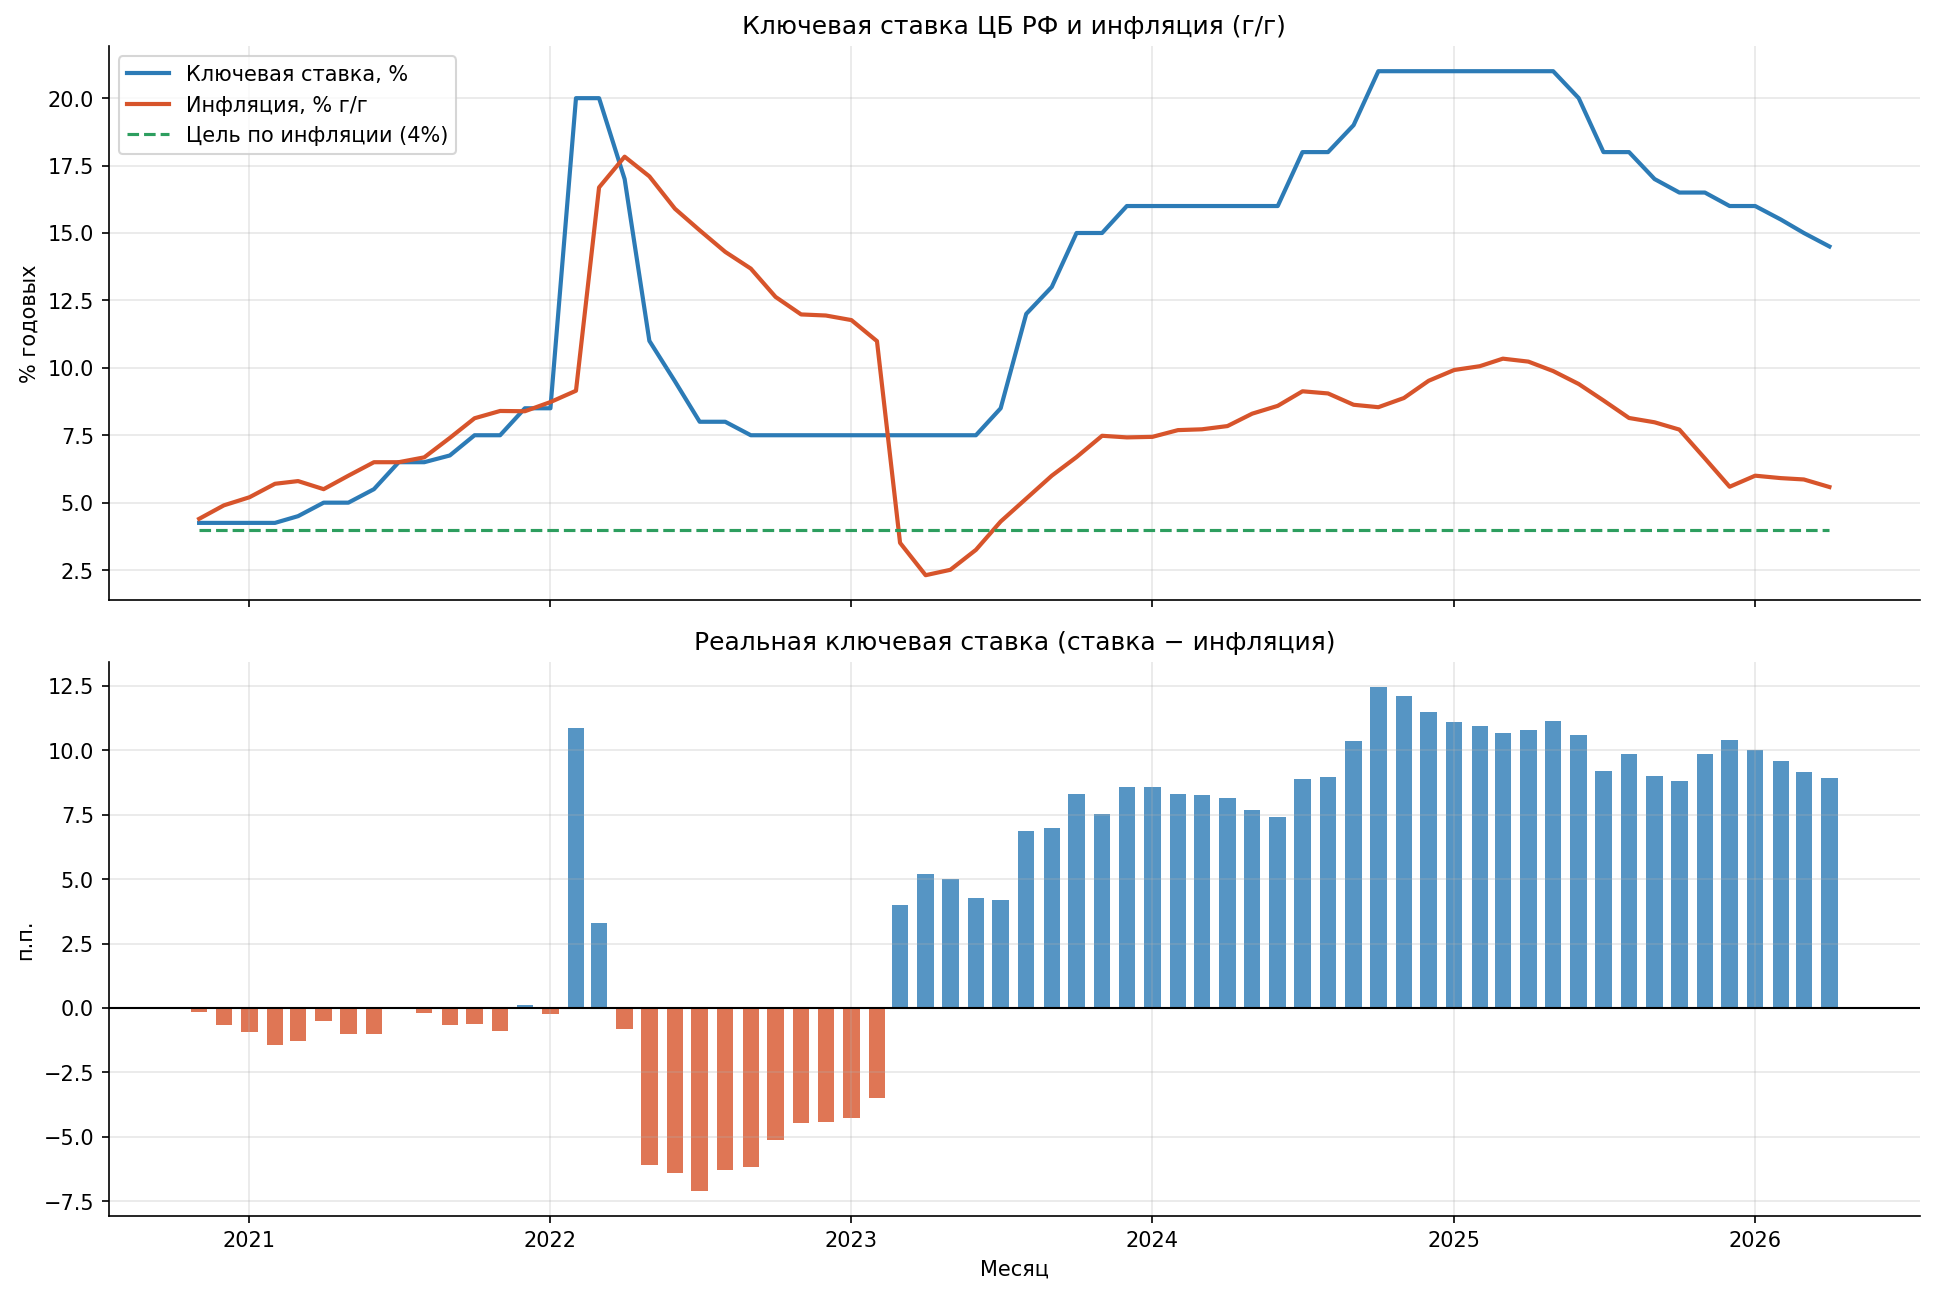

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

ax = axes[0]
ax.plot(macro["date"], macro["key_rate"],  color=C1, lw=2,   label="Ключевая ставка, %")
ax.plot(macro["date"], macro["inflation"], color=C2, lw=2,   label="Инфляция, % г/г")
ax.plot(macro["date"], macro["target"],    color=C3, lw=1.5, ls="--", label="Цель по инфляции (4%)")
ax.set_ylabel("% годовых")
ax.set_title("Ключевая ставка ЦБ РФ и инфляция (г/г)")
ax.legend(loc="upper left")

ax = axes[1]
colors = np.where(macro["real_rate"] >= 0, C1, C2)
ax.bar(macro["date"], macro["real_rate"], width=20, color=colors, alpha=0.8)
ax.axhline(0, color="black", lw=1)
ax.set_ylabel("п.п.")
ax.set_xlabel("Месяц")
ax.set_title("Реальная ключевая ставка (ставка − инфляция)")

fig.tight_layout(rect=(0, 0, 1, 0.97))
fig.savefig(FIG_DIR / "fig01_key_rate_inflation.png", bbox_inches="tight")
plt.show()


## Вывод

- **Три режима за период данных:** низкая ставка 4.25% (2020–2021, дешёвая ипотека и льготные
  программы → бум спроса на первичку) → резкий скачок в 2022 → новое ужесточение 2024–2025
  (ставка 16–21%, инфляция стабильно выше цели 4%).
- **Реальная ставка** большую часть 2024–2025 сильно положительная — жёсткая ДКП, дорогая ипотека,
  давление на спрос.
- **Связь с проектом:** ставка задаёт стоимость ипотеки и фон спроса, поэтому ценовая эластичность,
  которую мы оцениваем по 2023–2025, измеряется в среде меняющегося макро-фона — это ограничение
  интерпретации (эффект цены частично смешан с эффектом ставки/доступности ипотеки).
